In [35]:
import re
import json
from dataclasses import dataclass, asdict
from typing import List

@dataclass(slots=True)
class Point:
    ''' Cartesian point '''
    x: float = 0.0
    y: float = 0.0

def parse_gcode(file_path: str) -> List[Point]:
    points = []
    current_x, current_y = 0.0, 0.0

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            # Match only G0 or G1 lines that contain X or Y
            if line.startswith(('G0', 'G1')) and ('X' in line or 'Y' in line):
                x_match = re.search(r'X\s*(-?\d+\.?\d*)', line)
                y_match = re.search(r'Y\s*(-?\d+\.?\d*)', line)

                if x_match:
                    current_x = float(x_match.group(1))
                    current_x = round(current_x/10, 6)
                if y_match:
                    current_y = float(y_match.group(1))
                    current_y = round(current_y/10, 6)

                points.append(Point(x=current_x, y=current_y))
    return points

def save_points_to_json(points: List[Point], output_path: str):
    json_data = [asdict(point) for point in points]
    with open(output_path, 'w') as f:
        json.dump(json_data, f, indent=4)

# Example usage
if __name__ == "__main__":
    gcode_file = 'circle_ws.gcode'     # Replace with your actual file path
    json_output = 'circle_ws.json'      # Output JSON file path

    extracted_points = parse_gcode(gcode_file)
    save_points_to_json(extracted_points, json_output)
    print(f"Extracted {len(extracted_points)} points and saved to {json_output}")


Extracted 163 points and saved to circle_ws.json


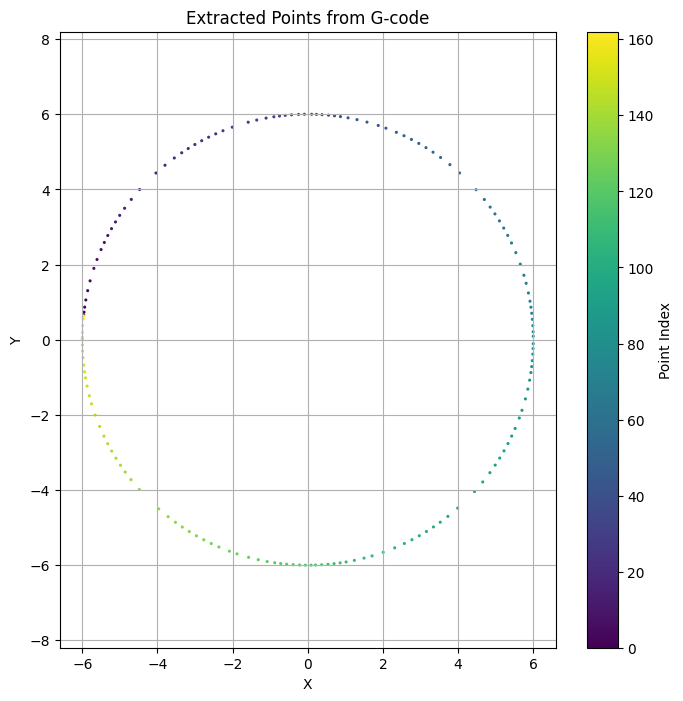

In [36]:
# plot the points in xy plane
import matplotlib.pyplot as plt

x_vals = [point.x for point in extracted_points]
y_vals = [point.y for point in extracted_points]
idx = [i for i in range(len(extracted_points))]
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=idx, cmap='viridis', s=1.5)
plt.colorbar(label='Point Index')
plt.title('Extracted Points from G-code')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.axis('equal')
plt.show()